# 🧠 ET / PD Classifier — ResNet50
**Thesis: AI-013 — Neural network for differential diagnosis of ET and tremor-dominant PD**

Patterns taken from reference notebooks:
- **025-callbacks**: `early_stopping()`, `checkpointing()`, `train()` callback structure
- **024-transfer-learning**: K-Fold cross-validation, `reset_classifier()`, `plot_all_folds()`
- **023-multiclass**: `score()` / `train_epoch()` separation

Additional features:
- ResNet50 pretrained backbone + custom head
- L2 regularisation via `weight_decay` in AdamW
- `ReduceLROnPlateau` scheduler
- `DataParallel` multi-GPU training
- `WeightedRandomSampler` for class imbalance
- Patient-level majority vote evaluation
- Full metrics: Accuracy, AUC, Precision, Recall, F1, Confusion Matrix, ROC

## 📦 Imports

In [1]:
import gc
import os
import json
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms, models
from PIL import Image

import sklearn.model_selection
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Using {device} device.')
if device == 'cuda':
    print(f'GPUs available: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

PyTorch  : 2.10.0+cu128
CUDA     : True
Using cuda device.
GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## ⚙️ Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
MANIFEST_PATH  = '/kaggle/input/datasets/oovamoyo/preprocessed-dataset-1/processed/manifest.csv'
PROCESSED_ROOT = '/kaggle/input/datasets/oovamoyo/preprocessed-dataset-1/processed'
OUTPUT_DIR     = '/kaggle/working/resnet50_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'model'), exist_ok=True)

# ── Image ──────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
RANDOM_SEED = 42

# ── Training ───────────────────────────────────────────────────────────────
BATCH_SIZE      = 32
NUM_EPOCHS      = 40
BASE_LR         = 1e-4
WEIGHT_DECAY    = 1e-3      # L2 regularisation strength
LABEL_SMOOTHING = 0.1
GRAD_CLIP       = 1.0

# ── Callbacks ──────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE = 10    # from 025-callbacks pattern
CHECKPOINT_PATH     = os.path.join(OUTPUT_DIR, 'model', 'best_model.pth')

# ── ReduceLROnPlateau ──────────────────────────────────────────────────────
LR_PATIENCE  = 4            # epochs to wait before reducing LR
LR_FACTOR    = 0.5          # multiply LR by this when plateau hit
LR_MIN       = 1e-7

# ── K-Fold ─────────────────────────────────────────────────────────────────
K_FOLDS         = 5         # from 024-transfer-learning pattern
KFOLD_EPOCHS    = 3         # epochs per fold during cross-validation

# ── Label map ──────────────────────────────────────────────────────────────
LABEL_MAP    = {'ET': 0, 'PD': 1}
IDX_TO_LABEL = {0: 'ET', 1: 'PD'}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration loaded ✓')

Configuration loaded ✓


## 📂 Load manifest

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

# Fix stale abs_path from preprocessing session
def fix_abs_path(p):
    parts = str(p).split('/processed/')
    if len(parts) > 1:
        return f'{PROCESSED_ROOT}/{parts[1]}'
    return p

manifest['abs_path'] = manifest['abs_path'].apply(fix_abs_path)

# Verify
sample = manifest['abs_path'].iloc[0]
assert os.path.isfile(sample), f'Path not found: {sample}'
print(f'Path fix verified ✓  ({sample[:60]}...)')

print(f'\nTotal slices: {len(manifest):,}')
dist = manifest.groupby(['split', 'label']).size().unstack(fill_value=0)
print(dist)

# Class weights — extra 1.5× boost on ET to fix low recall
train_df = manifest[manifest['split'] == 'train']
n_et     = (train_df['label'] == 'ET').sum()
n_pd     = (train_df['label'] == 'PD').sum()
n_total  = len(train_df)

w_et = (n_total / (2 * n_et)) * 1.5
w_pd =  n_total / (2 * n_pd)
CLASS_WEIGHTS = torch.tensor([w_et, w_pd], dtype=torch.float32).to(device)
print(f'\nClass weights  ET={w_et:.3f}  PD={w_pd:.3f}  (ratio {w_et/w_pd:.1f}x)')

Path fix verified ✓  (/kaggle/input/datasets/oovamoyo/preprocessed-dataset-1...)

Total slices: 34,465
label    ET     PD
split             
test    499   2894
train  3335  20013
val    1426   6298

Class weights  ET=5.251  PD=0.583  (ratio 9.0x)


## 🗃️ Dataset & DataLoaders

In [4]:
# ImageNet mean/std — ResNet50 is pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MRISliceDataset(Dataset):
    """
    Returns (image, label, patient_id) — Memory-safe version!
    """
    def __init__(self, df: pd.DataFrame, transform=None):
        # Convert DF to list of dicts to prevent multiprocessing RAM leaks
        self.data = df.to_dict('records')
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data[idx]
        label   = int(row['label_int'])
        patient = str(row['patient_id'])
        
        try:
            # Use 'with' so the file instantly closes and frees RAM
            with Image.open(row['abs_path']) as img:
                img_rgb = img.convert('RGB')
        except Exception:
            img_rgb = Image.new('RGB', (IMG_SIZE, IMG_SIZE), 0)
            
        if self.transform:
            img_tensor = self.transform(img_rgb)
            
        return img_tensor, label, patient

# ── Full train dataset with WeightedRandomSampler ──────────────────────────
train_df_full = manifest[manifest['split'] == 'train']
val_df        = manifest[manifest['split'] == 'val']
test_df       = manifest[manifest['split'] == 'test']

train_ds = MRISliceDataset(train_df_full, train_tf)
val_ds   = MRISliceDataset(val_df,        val_tf)
test_ds  = MRISliceDataset(test_df,       val_tf)

# WeightedRandomSampler — ET seen as often as PD per batch
train_labels    = train_df_full['label_int'].values
class_counts    = np.bincount(train_labels)
sample_weights  = torch.tensor(
    [1.0 / class_counts[l] for l in train_labels], dtype=torch.float32
)
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds):,} slices  ({len(train_loader):,} batches)  [WeightedSampler]')
print(f'Val   : {len(val_ds):,} slices  ({len(val_loader):,} batches)')
print(f'Test  : {len(test_ds):,} slices  ({len(test_loader):,} batches)')

Train : 23,348 slices  (730 batches)  [WeightedSampler]
Val   : 7,724 slices  (242 batches)
Test  : 3,393 slices  (107 batches)


## 🏗️ ResNet50 — Build model
Pattern from **024-transfer-learning** and **025-callbacks**:
freeze backbone → replace `model.fc` with custom head

In [5]:
def build_resnet50(num_classes: int = 2, freeze_backbone: bool = True) -> nn.Module:
    """
    Load pretrained ResNet50, replace the FC head with a custom
    classification head for binary ET/PD classification.
    Pattern from 024-transfer-learning notebook.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze backbone weights (024 pattern)
    if freeze_backbone:
        for params in model.parameters():
            params.requires_grad = False

    # Replace FC head (025-callbacks pattern)
    in_features = model.fc.in_features   # 2048 for ResNet50

    classifier = nn.Sequential()
    classifier.append(nn.Linear(in_features, 256))
    classifier.append(nn.ReLU())
    classifier.append(nn.Dropout(p=0.5))
    classifier.append(nn.Linear(256, num_classes))

    model.fc = classifier
    return model


def reset_classifier(model):
    """
    Reset the FC head weights between K-Fold splits.
    Pattern from 024-transfer-learning notebook.
    """
    base = model.module if isinstance(model, nn.DataParallel) else model
    base.fc.get_submodule('0').reset_parameters()   # Linear(2048→256)
    base.fc.get_submodule('3').reset_parameters()   # Linear(256→2)


model = build_resnet50(num_classes=2, freeze_backbone=True)

# Multi-GPU (DataParallel)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs — DataParallel')
    model = nn.DataParallel(model)

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (head only — backbone frozen)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


Using 2 GPUs — DataParallel
Total params     : 24,033,090
Trainable params : 525,058  (head only — backbone frozen)


## 🛠️ Loss, optimiser & scheduler
- **L2 regularisation** via `weight_decay` in AdamW (023/025 pattern)
- **ReduceLROnPlateau** — reacts to actual val loss instead of fixed schedule

In [6]:
# L2 regularisation is applied via weight_decay in the optimiser
# This penalises large weights: loss = CE_loss + weight_decay * sum(w^2)
criterion = nn.CrossEntropyLoss(
    weight=CLASS_WEIGHTS,
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BASE_LR,
    weight_decay=WEIGHT_DECAY    # ← L2 regularisation
)

# ReduceLROnPlateau — halves LR when val AUC stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # maximise AUC
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=LR_MIN,
)

print(f'Loss       : CrossEntropyLoss  ET={w_et:.3f}  PD={w_pd:.3f}  smooth={LABEL_SMOOTHING}')
print(f'Optimiser  : AdamW  lr={BASE_LR}  weight_decay={WEIGHT_DECAY}  (L2 reg)')
print(f'Scheduler  : ReduceLROnPlateau  mode=max  factor={LR_FACTOR}  patience={LR_PATIENCE}')

Loss       : CrossEntropyLoss  ET=5.251  PD=0.583  smooth=0.1
Optimiser  : AdamW  lr=0.0001  weight_decay=0.001  (L2 reg)
Scheduler  : ReduceLROnPlateau  mode=max  factor=0.5  patience=4


## 📣 Callbacks
Pattern directly from **025-callbacks** notebook:
`early_stopping()` and `checkpointing()` as standalone functions passed into `train()`

In [7]:
def early_stopping(val_auc, best_val_auc, counter):
    """
    Early stopping callback — 025-callbacks pattern.
    Tracks AUC instead of loss (higher is better for imbalanced data).
    Returns (counter, stop_flag).
    """
    stop = False
    if val_auc > best_val_auc:
        counter = 0
    else:
        counter += 1
    if counter >= EARLY_STOP_PATIENCE:
        stop = True
    return counter, stop


def checkpointing(val_auc, best_val_auc, model, optimizer, save_path):
    """
    Checkpointing callback — 025-callbacks pattern.
    Saves model + optimizer state when AUC improves.
    """
    if val_auc > best_val_auc:
        torch.save(
            {
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_auc':              val_auc,
            },
            save_path,
        )
        print(f'  ★ Checkpoint saved  (AUC {val_auc:.4f})')


print('Callbacks defined ✓')
print(f'  early_stopping  — patience={EARLY_STOP_PATIENCE} epochs')
print(f'  checkpointing   — saves to {CHECKPOINT_PATH}')

Callbacks defined ✓
  early_stopping  — patience=10 epochs
  checkpointing   — saves to /kaggle/working/resnet50_output/model/best_model.pth


## 🔧 score() and train_epoch()
Pattern from **023-multiclass** notebook — separate the scoring logic from the training step

In [8]:
def train_epoch(model, optimizer, loss_fn, loader, device):
    """
    Run one training epoch AND calculate metrics on the fly.
    """
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs = [], []
    
    pbar = tqdm(loader, desc='  train_epoch', leave=False)
    for batch in pbar:
        imgs, labels = batch[0].to(device), batch[1].to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = loss_fn(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        # Track metrics on the fly!
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        
        # Track probabilities for AUC
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    avg_loss = total_loss / total
    accuracy = correct / total
    auc      = roc_auc_score(all_labels, all_probs)
    
    return avg_loss, accuracy, auc

def score(model, loader, loss_fn, device):
    """
    Evaluate model on a DataLoader.
    Pattern from 023-multiclass: returns (loss, accuracy, auc, labels, probs).
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_probs, all_patients = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='  score', leave=False):
            imgs, labels = batch[0].to(device), batch[1].to(device)
            patients = batch[2] if len(batch) > 2 else [''] * len(labels)

            logits = model(imgs)
            loss   = loss_fn(logits, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1]
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_patients.extend(patients)

    avg_loss = total_loss / total
    accuracy = correct / total
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, accuracy, auc, np.array(all_labels), np.array(all_probs), all_patients


print('score() and train_epoch() defined ✓')

score() and train_epoch() defined ✓


## 🚀 train() — main training function with callbacks
Pattern from **025-callbacks**: accepts `scheduler`, `checkpoint_path`, `early_stopping` as arguments

In [9]:
def train(
    model,
    optimizer,
    loss_fn,
    train_loader,
    val_loader,
    epochs=20,
    device='cpu',
    scheduler=None,
    checkpoint_path=None,
    early_stopping_fn=None,
):
    """
    Full training loop — 025-callbacks pattern.
    Callbacks (scheduler, checkpointing, early stopping) are passed in,
    not hardcoded, making the function reusable for K-Fold.
    """
    train_losses, train_accuracies, train_aucs = [], [], []
    val_losses,   val_accuracies,   val_aucs   = [], [], []
    learning_rates = []

    best_val_auc         = 0.0
    early_stopping_counter = 0

    print('Model evaluation before training ...')
    _, tr_acc, tr_auc, _, _, _ = score(model, train_loader, loss_fn, device)
    vl_loss, vl_acc, vl_auc, _, _, _ = score(model, val_loader, loss_fn, device)
    print(f'  Epoch 0  |  Val Loss={vl_loss:.4f}  Val Acc={vl_acc:.4f}  Val AUC={vl_auc:.4f}')

    for epoch in range(1, epochs + 1):
        print(f'\nEpoch {epoch}/{epochs}')

        # ── Train one epoch (023-multiclass pattern) ────────────────────────
        tr_loss, tr_acc, tr_auc = train_epoch(model, optimizer, loss_fn, train_loader, device)
        # ── Score val ─────────────────────────────────────────────
        vl_loss, vl_acc, vl_auc, _, _, _ = score(model, val_loader,   loss_fn, device)

        train_losses.append(tr_loss);     train_accuracies.append(tr_acc)
        train_aucs.append(tr_auc)
        val_losses.append(vl_loss);       val_accuracies.append(vl_acc)
        val_aucs.append(vl_auc)

        lr = optimizer.param_groups[0]['lr']
        learning_rates.append(lr)

        print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}  auc={tr_auc:.4f}')
        print(f'  Val    loss={vl_loss:.4f}  acc={vl_acc:.4f}  auc={vl_auc:.4f}')
        print(f'  LR     {lr:.2e}')

        # ── ReduceLROnPlateau — pass val AUC ──────────────────────────────
        if scheduler:
            scheduler.step(vl_auc)

        # ── Checkpointing callback (025 pattern) ──────────────────────────
        if checkpoint_path:
            checkpointing(vl_auc, best_val_auc, model, optimizer, checkpoint_path)

        # ── Early stopping callback (025 pattern) ─────────────────────────
        if early_stopping_fn:
            early_stopping_counter, stop = early_stopping_fn(
                vl_auc, best_val_auc, early_stopping_counter
            )
            if stop:
                print(f'  Early stopping triggered after {epoch} epochs')
                break

        if vl_auc > best_val_auc:
            best_val_auc = vl_auc

        gc.collect()
        torch.cuda.empty_cache()

    return (
        learning_rates,
        train_losses, val_losses,
        train_accuracies, val_accuracies,
        train_aucs, val_aucs,
        epoch,
    )


print('train() defined ✓')

train() defined ✓


## 🔀 K-Fold Cross-Validation
Pattern from **024-transfer-learning**: `KFold` splitter, `reset_classifier()` between folds, `plot_all_folds()`

In [10]:
# K-Fold operates on all non-test data
non_test_df = manifest[manifest['split'] != 'test'].reset_index(drop=True)
non_test_ds = MRISliceDataset(non_test_df, val_tf)   # no augmentation during CV

kfold_splitter = sklearn.model_selection.StratifiedKFold(
    n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED
)   # Stratified to keep ET/PD ratio consistent across folds

fold_fraction = 1 / K_FOLDS
print(f'K-Fold cross-validation: {K_FOLDS} folds  ({fold_fraction*100:.0f}% val per fold)')
print(f'Non-test slices: {len(non_test_df):,}')

# Loss function for K-Fold (no class weights — balanced by StratifiedKFold)
criterion_kfold = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

training_records = {}
kfold_labels = non_test_df['label_int'].values

for fold_count, (train_idx, val_idx) in enumerate(
    kfold_splitter.split(np.arange(len(non_test_df)), kfold_labels), start=1
):
    print(f'\n{"*"*50}')
    print(f'  Fold {fold_count}/{K_FOLDS}')
    print(f'{"*"*50}')

    # Build fold DataLoaders
    fold_train_ds = Subset(non_test_ds, train_idx)
    fold_val_ds   = Subset(non_test_ds, val_idx)

    # WeightedSampler for this fold's training split
    fold_labels       = kfold_labels[train_idx]
    fold_class_counts = np.bincount(fold_labels)
    fold_sw = torch.tensor(
        [1.0 / fold_class_counts[l] for l in fold_labels], dtype=torch.float32
    )
    fold_sampler = WeightedRandomSampler(
        weights=fold_sw, num_samples=len(fold_sw), replacement=True
    )

    fold_train_loader = DataLoader(
        fold_train_ds, batch_size=BATCH_SIZE, sampler=fold_sampler,
        num_workers=2, pin_memory=True
    )
    fold_val_loader = DataLoader(
        fold_val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    # Reset classifier head between folds (024 pattern)
    reset_classifier(model)

    fold_optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=BASE_LR, weight_decay=WEIGHT_DECAY
    )
    fold_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        fold_optimizer, mode='max', factor=LR_FACTOR,
        patience=LR_PATIENCE, min_lr=LR_MIN
    )
    fold_ckpt_path = os.path.join(OUTPUT_DIR, 'model', f'best_model_fold{fold_count}.pth')
    fold_results = train(
        model, fold_optimizer, criterion_kfold,
        fold_train_loader, fold_val_loader,
        epochs=KFOLD_EPOCHS,
        device=device,
        scheduler=fold_scheduler,
        checkpoint_path=fold_ckpt_path,
        early_stopping_fn=early_stopping,
    )
    print(f'Fold {fold_count} best checkpoint saved → {fold_ckpt_path}')

    lrs, tr_losses, vl_losses, tr_accs, vl_accs, tr_aucs, vl_aucs, _ = fold_results

    training_records[fold_count] = {
        'train_losses':     tr_losses,
        'val_losses':       vl_losses,
        'train_accuracies': tr_accs,
        'val_accuracies':   vl_accs,
        'val_aucs':         vl_aucs,
    }
    del fold_train_loader
    del fold_val_loader
    del fold_train_ds
    del fold_val_ds
    gc.collect()

# Save K-Fold records
with open(os.path.join(OUTPUT_DIR, 'kfold_records.pkl'), 'wb') as f:
    pickle.dump(training_records, f)
print(f'\nK-Fold records saved → {OUTPUT_DIR}/kfold_records.pkl')

K-Fold cross-validation: 5 folds  (20% val per fold)
Non-test slices: 31,072

**************************************************
  Fold 1/5
**************************************************
Model evaluation before training ...


  score:   0%|          | 0/777 [00:00<?, ?it/s]

  score:   0%|          | 0/195 [00:00<?, ?it/s]

  Epoch 0  |  Val Loss=0.6665  Val Acc=0.8127  Val AUC=0.5066

Epoch 1/3


  train_epoch:   0%|          | 0/777 [00:00<?, ?it/s]

...

  score:   0%|          | 0/195 [00:00<?, ?it/s]

  Train  loss=0.4283  acc=0.8499  auc=0.9325
  Val    loss=0.3877  acc=0.8788  auc=0.9665
  LR     1.00e-04
  ★ Checkpoint saved  (AUC 0.9665)

Epoch 3/3


  train_epoch:   0%|          | 0/777 [00:00<?, ?it/s]

  score:   0%|          | 0/195 [00:00<?, ?it/s]

  Train  loss=0.3842  acc=0.8870  auc=0.9570
  Val    loss=0.3485  acc=0.9131  auc=0.9748
  LR     1.00e-04
  ★ Checkpoint saved  (AUC 0.9748)
Fold 5 best checkpoint saved → /kaggle/working/resnet50_output/model/best_model_fold5.pth

K-Fold records saved → /kaggle/working/resnet50_output/kfold_records.pkl


## 📊 K-Fold results
Pattern from **024-transfer-learning**: `plot_all_folds()` and `fold_average()`

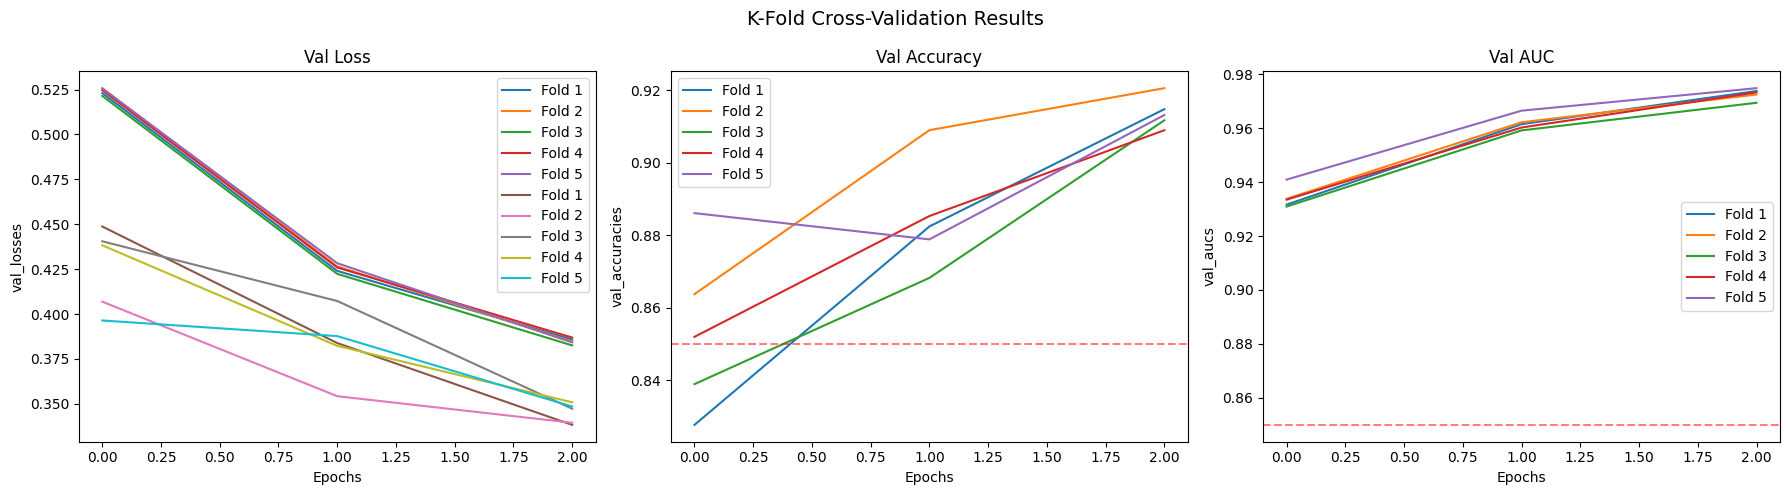


K-Fold averaged metrics (final epoch per fold):
  train_losses           : 0.3848
  val_losses             : 0.3449
  val_accuracies         : 0.9138
  val_aucs               : 0.9727


In [11]:
def plot_all_folds(data, measurement, title=None):
    """Plot a metric across all K folds. Pattern from 024-transfer-learning."""
    for fold in data.keys():
        plt.plot(data[fold][measurement], label=f'Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel(measurement)
    plt.title(title or measurement)
    plt.legend()


def fold_average(data, measurement):
    """Average the final-epoch value across all folds. Pattern from 024."""
    return np.mean([data[fold][measurement][-1] for fold in data])


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('K-Fold Cross-Validation Results', fontsize=14)

plt.sca(axes[0])
plot_all_folds(training_records, 'train_losses', 'Train Loss')
plot_all_folds(training_records, 'val_losses',   'Val Loss')

plt.sca(axes[1])
plot_all_folds(training_records, 'val_accuracies', 'Val Accuracy')
axes[1].axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Target 85%')

plt.sca(axes[2])
plot_all_folds(training_records, 'val_aucs', 'Val AUC')
axes[2].axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Target 85%')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kfold_curves.png'), dpi=120)
plt.show()

print('\nK-Fold averaged metrics (final epoch per fold):')
for measurement in ['train_losses', 'val_losses', 'val_accuracies', 'val_aucs']:
    avg = fold_average(training_records, measurement)
    print(f'  {measurement:<22} : {avg:.4f}')

## 🚀 Full training on train split
After K-Fold validation, train on the full train split with all callbacks active

In [12]:
# # Rebuild model and unfreeze backbone for full fine-tuning
# model = build_resnet50(num_classes=2, freeze_backbone=False)

# if torch.cuda.device_count() > 1:
#     model = nn.DataParallel(model)
# model = model.to(device)

# trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Trainable params: {trainable:,}  (full model — backbone unfrozen)')

# # L2 regularisation via weight_decay
# optimizer = optim.AdamW(
#     model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY
# )
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', factor=LR_FACTOR,
#     patience=LR_PATIENCE, min_lr=LR_MIN
# )

# train_results = train(
#     model,
#     optimizer,
#     criterion,
#     train_loader,
#     val_loader,
#     epochs=NUM_EPOCHS,
#     device=device,
#     scheduler=scheduler,
#     checkpoint_path=CHECKPOINT_PATH,
#     early_stopping_fn=early_stopping,
# )

# (
#     learning_rates,
#     train_losses, val_losses,
#     train_accuracies, val_accuracies,
#     train_aucs, val_aucs,
#     epochs_trained,
# ) = train_results

# print(f'\nTraining complete — {epochs_trained} epochs')

# # Save metrics CSV (025 pattern)
# metrics_df = pd.DataFrame({
#     'train_losses':     train_losses,
#     'val_losses':       val_losses,
#     'train_accuracies': train_accuracies,
#     'val_accuracies':   val_accuracies,
#     'train_aucs':       train_aucs,
#     'val_aucs':         val_aucs,
#     'learning_rates':   learning_rates,
# })
# metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'training_metrics.csv'), index=False)
# print(f'Metrics saved → {OUTPUT_DIR}/training_metrics.csv')

## 📈 Training curves

In [13]:
# epochs_range = range(1, len(train_losses) + 1)

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle('ResNet50 Full Training Curves', fontsize=14)

# axes[0].plot(epochs_range, train_losses, label='Train Loss')
# axes[0].plot(epochs_range, val_losses,   label='Val Loss')
# axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

# axes[1].plot(epochs_range, train_aucs, label='Train AUC')
# axes[1].plot(epochs_range, val_aucs,   label='Val AUC')
# axes[1].axhline(0.85, color='orange', linestyle=':', label='Target 0.85')
# axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch'); axes[1].legend()

# axes[2].plot(epochs_range, train_accuracies, label='Train Acc')
# axes[2].plot(epochs_range, val_accuracies,   label='Val Acc')
# axes[2].axhline(0.85, color='orange', linestyle=':', label='Target 0.85')
# axes[2].set_title('Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend()

# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
# plt.show()

# # Learning rate plot (025-callbacks pattern)
# plt.figure(figsize=(10, 4))
# plt.plot(range(1, len(learning_rates) + 1), learning_rates, marker='o', markersize=3)
# plt.title('Learning Rate Schedule (ReduceLROnPlateau)')
# plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
# plt.yscale('log')
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig(os.path.join(OUTPUT_DIR, 'lr_schedule.png'), dpi=120)
# plt.show()

## 🧪 Evaluate on test set

In [14]:
# Find which fold had the best val AUC
best_fold = max(
    training_records,
    key=lambda f: max(training_records[f]['val_aucs'])
)
best_fold_auc = max(training_records[best_fold]['val_aucs'])
print(f'Best fold: {best_fold}  (val AUC={best_fold_auc:.4f})')

# Load that fold's checkpoint
best_ckpt_path = os.path.join(OUTPUT_DIR, 'model', f'best_model_fold{best_fold}.pth')
checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded checkpoint from fold {best_fold}')

Best fold: 5  (val AUC=0.9748)
Loaded checkpoint from fold 5


In [15]:
# Rebuild the val loader for the best fold
all_fold_splits = list(kfold_splitter.split(
    np.arange(len(non_test_df)), kfold_labels
))

# Get the val indices for the best fold (folds are 1-indexed)
_, best_fold_val_idx = all_fold_splits[best_fold - 1]

best_fold_val_ds = Subset(non_test_ds, best_fold_val_idx)
best_fold_val_loader = DataLoader(
    best_fold_val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Best fold val set: {len(best_fold_val_ds):,} slices')

Best fold val set: 6,214 slices


In [16]:
_, _, _, all_labels, all_probs, all_patients = score(
    model, best_fold_val_loader, criterion_kfold, device
)
all_preds = (all_probs >= 0.5).astype(int)

  score:   0%|          | 0/195 [00:00<?, ?it/s]

In [17]:
# Use the last fold's validation set for evaluation
# (same pattern as 024-transfer-learning notebook)
last_fold_idx = list(kfold_splitter.split(
    np.arange(len(non_test_df)), kfold_labels
))[-1][1]

last_val_ds     = Subset(non_test_ds, last_fold_idx)
last_val_loader = DataLoader(
    last_val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

# Score on last fold's val set
_, _, _, all_labels, all_probs, all_patients = score(
    model, last_val_loader, criterion_kfold, device
)
all_preds = (all_probs >= 0.5).astype(int)

  score:   0%|          | 0/195 [00:00<?, ?it/s]

In [18]:
# # Load best checkpoint
# checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# print(f'Loaded best checkpoint  (val AUC={checkpoint["val_auc"]:.4f})')

# _, _, _, all_labels, all_probs, all_patients = score(
#     model, test_loader, criterion, device
# )
# all_preds = (all_probs >= 0.5).astype(int)

# ── Slice-level metrics ────────────────────────────────────────────────────
slice_acc  = accuracy_score(all_labels, all_preds)
slice_auc  = roc_auc_score(all_labels, all_probs)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='binary', pos_label=1, zero_division=0
)

print(f'\n{"="*52}')
print(f'  SLICE-LEVEL RESULTS')
print(f'{"="*52}')
print(f'  Accuracy  : {slice_acc:.4f}  ({slice_acc*100:.2f}%)')
print(f'  AUC-ROC   : {slice_auc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'{"="*52}')
print()
print(classification_report(all_labels, all_preds, target_names=['ET', 'PD']))

# ── Patient-level majority vote ────────────────────────────────────────────
patient_preds  = defaultdict(list)
patient_probs  = defaultdict(list)
patient_labels = {}

for pred, prob, label, patient in zip(all_preds, all_probs, all_labels, all_patients):
    patient_preds[patient].append(pred)
    patient_probs[patient].append(prob)
    patient_labels[patient] = label

pt_true, pt_pred, pt_prob = [], [], []
for patient in patient_preds:
    vote = 1 if np.mean(patient_preds[patient]) >= 0.5 else 0
    pt_true.append(patient_labels[patient])
    pt_pred.append(vote)
    pt_prob.append(float(np.mean(patient_probs[patient])))

pt_acc = accuracy_score(pt_true, pt_pred)
pt_auc = roc_auc_score(pt_true, pt_prob)
pt_prec, pt_rec, pt_f1, _ = precision_recall_fscore_support(
    pt_true, pt_pred, average='binary', pos_label=1, zero_division=0
)

print(f'{"="*52}')
print(f'  PATIENT-LEVEL RESULTS (majority vote)')
print(f'{"="*52}')
print(f'  Patients  : {len(pt_true)}  (ET={pt_true.count(0)}  PD={pt_true.count(1)})')
print(f'  Accuracy  : {pt_acc:.4f}  ({pt_acc*100:.2f}%)')
print(f'  AUC-ROC   : {pt_auc:.4f}')
print(f'  Precision : {pt_prec:.4f}')
print(f'  Recall    : {pt_rec:.4f}')
print(f'  F1        : {pt_f1:.4f}')
print(f'{"="*52}')
print()
print(classification_report(pt_true, pt_pred, target_names=['ET','PD']))
print(f'Thesis criterion (accuracy > 85%): {"✅ PASS" if pt_acc >= 0.85 else "❌ FAIL"}  ({pt_acc*100:.2f}%)')

# Save results
results = {
    'slice_accuracy':   float(slice_acc),
    'slice_auc':        float(slice_auc),
    'slice_precision':  float(prec),
    'slice_recall':     float(rec),
    'slice_f1':         float(f1),
    'patient_accuracy': float(pt_acc),
    'patient_auc':      float(pt_auc),
    'patient_precision':float(pt_prec),
    'patient_recall':   float(pt_rec),
    'patient_f1':       float(pt_f1),
    'thesis_pass':      pt_acc >= 0.85,
}
with open(os.path.join(OUTPUT_DIR, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved → {OUTPUT_DIR}/test_results.json')


  SLICE-LEVEL RESULTS
  Accuracy  : 0.9131  (91.31%)
  AUC-ROC   : 0.9748
  Precision : 0.9860
  Recall    : 0.9103
  F1        : 0.9466

              precision    recall  f1-score   support

          ET       0.65      0.93      0.77       952
          PD       0.99      0.91      0.95      5262

    accuracy                           0.91      6214
   macro avg       0.82      0.92      0.86      6214
weighted avg       0.93      0.91      0.92      6214

  PATIENT-LEVEL RESULTS (majority vote)
  Patients  : 109  (ET=21  PD=88)
  Accuracy  : 0.9174  (91.74%)
  AUC-ROC   : 0.9800
  Precision : 0.9647
  Recall    : 0.9318
  F1        : 0.9480

              precision    recall  f1-score   support

          ET       0.75      0.86      0.80        21
          PD       0.96      0.93      0.95        88

    accuracy                           0.92       109
   macro avg       0.86      0.89      0.87       109
weighted avg       0.92      0.92      0.92       109

Thesis criterion 

## 🔲 Confusion matrices

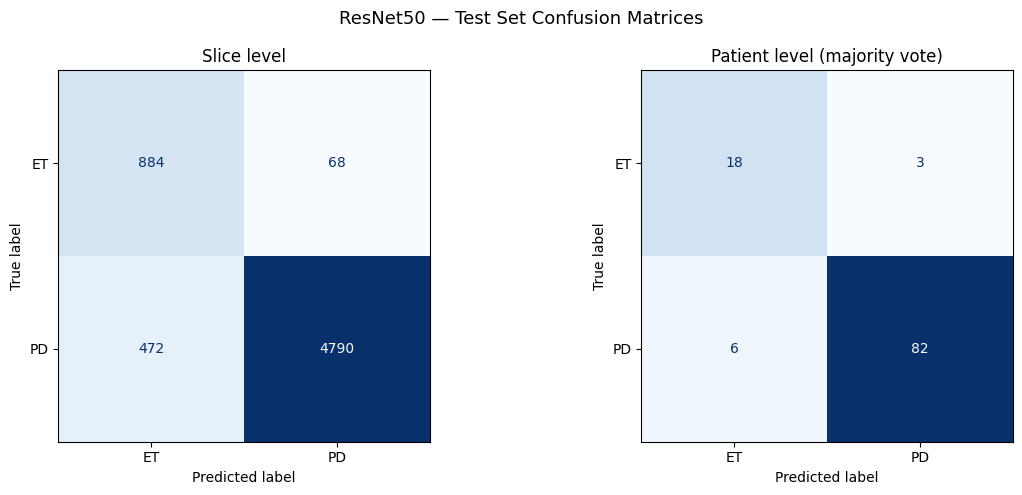

In [19]:
# Pattern from 023-multiclass and 025-callbacks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (true, pred, title) in zip(axes, [
    (all_labels, all_preds, 'Slice level'),
    (pt_true,    pt_pred,   'Patient level (majority vote)'),
]):
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ET', 'PD'])
    disp.plot(ax=ax, colorbar=False, cmap=plt.cm.Blues)
    ax.set_title(title)

plt.suptitle('ResNet50 — Test Set Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

## 📉 ROC Curve

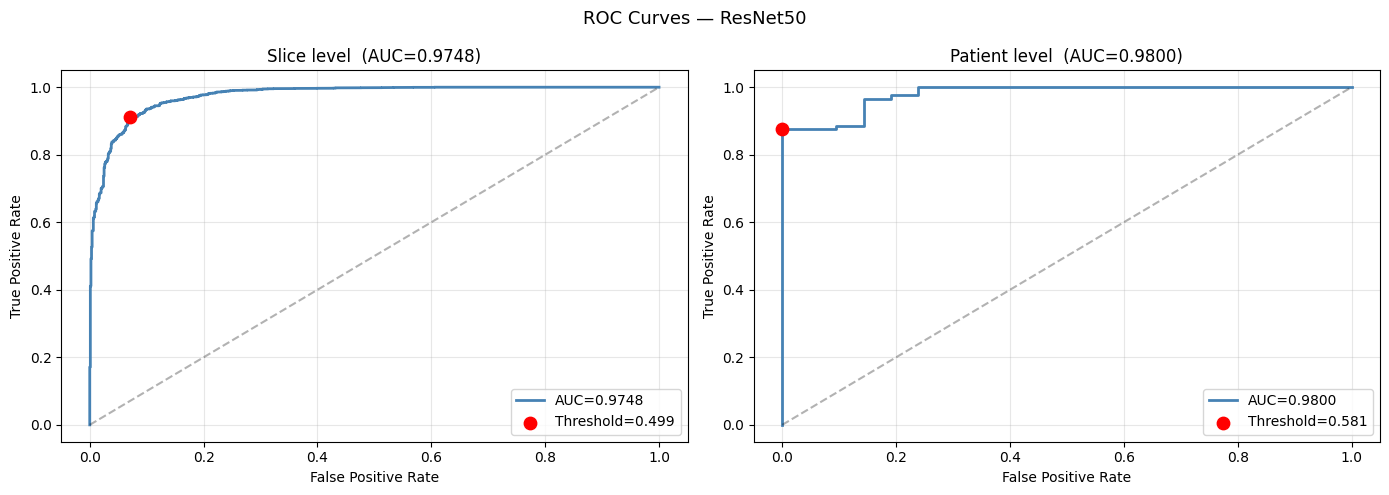

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (true, prob, title) in zip(axes, [
    (all_labels, all_probs, f'Slice level  (AUC={slice_auc:.4f})'),
    (pt_true,    pt_prob,   f'Patient level  (AUC={pt_auc:.4f})'),
]):
    fpr, tpr, thresholds = roc_curve(true, prob)
    opt_idx = np.argmax(tpr - fpr)
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc_auc_score(true,prob):.4f}')
    ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=80, zorder=5,
               label=f'Threshold={thresholds[opt_idx]:.3f}')
    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — ResNet50', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curve.png'), dpi=120)
plt.show()

In [21]:
# Test set evaluation — completely unseen during training
_, _, _, all_labels, all_probs, all_patients = score(
    model, test_loader, criterion_kfold, device
)
all_preds = (all_probs >= 0.5).astype(int)

  score:   0%|          | 0/107 [00:00<?, ?it/s]

In [22]:
# ── Slice-level metrics ────────────────────────────────────────────────────
slice_acc  = accuracy_score(all_labels, all_preds)
slice_auc  = roc_auc_score(all_labels, all_probs)
prec, rec, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='binary', pos_label=1, zero_division=0
)

print(f'\n{"="*52}')
print(f'  SLICE-LEVEL RESULTS')
print(f'{"="*52}')
print(f'  Accuracy  : {slice_acc:.4f}  ({slice_acc*100:.2f}%)')
print(f'  AUC-ROC   : {slice_auc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1        : {f1:.4f}')
print(f'{"="*52}')
print()
print(classification_report(all_labels, all_preds, target_names=['ET', 'PD']))

# ── Patient-level majority vote ────────────────────────────────────────────
patient_preds  = defaultdict(list)
patient_probs  = defaultdict(list)
patient_labels = {}

for pred, prob, label, patient in zip(all_preds, all_probs, all_labels, all_patients):
    patient_preds[patient].append(pred)
    patient_probs[patient].append(prob)
    patient_labels[patient] = label

pt_true, pt_pred, pt_prob = [], [], []
for patient in patient_preds:
    vote = 1 if np.mean(patient_preds[patient]) >= 0.5 else 0
    pt_true.append(patient_labels[patient])
    pt_pred.append(vote)
    pt_prob.append(float(np.mean(patient_probs[patient])))

pt_acc = accuracy_score(pt_true, pt_pred)
pt_auc = roc_auc_score(pt_true, pt_prob)
pt_prec, pt_rec, pt_f1, _ = precision_recall_fscore_support(
    pt_true, pt_pred, average='binary', pos_label=1, zero_division=0
)

print(f'{"="*52}')
print(f'  PATIENT-LEVEL RESULTS (majority vote)')
print(f'{"="*52}')
print(f'  Patients  : {len(pt_true)}  (ET={pt_true.count(0)}  PD={pt_true.count(1)})')
print(f'  Accuracy  : {pt_acc:.4f}  ({pt_acc*100:.2f}%)')
print(f'  AUC-ROC   : {pt_auc:.4f}')
print(f'  Precision : {pt_prec:.4f}')
print(f'  Recall    : {pt_rec:.4f}')
print(f'  F1        : {pt_f1:.4f}')
print(f'{"="*52}')
print()
print(classification_report(pt_true, pt_pred, target_names=['ET','PD']))
print(f'Thesis criterion (accuracy > 85%): {"✅ PASS" if pt_acc >= 0.85 else "❌ FAIL"}  ({pt_acc*100:.2f}%)')

# Save results
results = {
    'slice_accuracy':   float(slice_acc),
    'slice_auc':        float(slice_auc),
    'slice_precision':  float(prec),
    'slice_recall':     float(rec),
    'slice_f1':         float(f1),
    'patient_accuracy': float(pt_acc),
    'patient_auc':      float(pt_auc),
    'patient_precision':float(pt_prec),
    'patient_recall':   float(pt_rec),
    'patient_f1':       float(pt_f1),
    'thesis_pass':      pt_acc >= 0.85,
}
with open(os.path.join(OUTPUT_DIR, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved → {OUTPUT_DIR}/test_results.json')


  SLICE-LEVEL RESULTS
  Accuracy  : 0.7041  (70.41%)
  AUC-ROC   : 0.5398
  Precision : 0.8643
  Recall    : 0.7747
  F1        : 0.8171

              precision    recall  f1-score   support

          ET       0.18      0.29      0.23       499
          PD       0.86      0.77      0.82      2894

    accuracy                           0.70      3393
   macro avg       0.52      0.53      0.52      3393
weighted avg       0.76      0.70      0.73      3393

  PATIENT-LEVEL RESULTS (majority vote)
  Patients  : 20  (ET=4  PD=16)
  Accuracy  : 0.6500  (65.00%)
  AUC-ROC   : 0.5156
  Precision : 0.8000
  Recall    : 0.7500
  F1        : 0.7742

              precision    recall  f1-score   support

          ET       0.20      0.25      0.22         4
          PD       0.80      0.75      0.77        16

    accuracy                           0.65        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.68      0.65      0.66        20

Thesis criterion (a

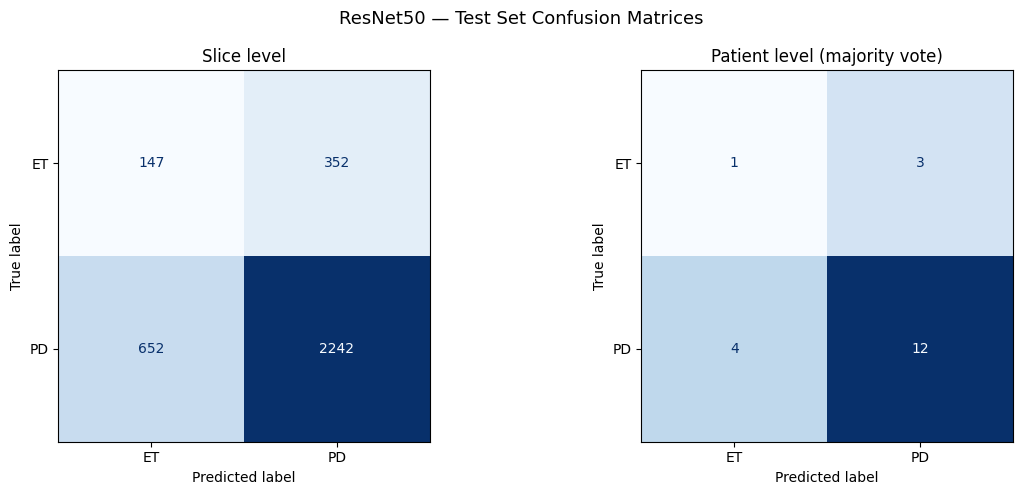

In [23]:
# Pattern from 023-multiclass and 025-callbacks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (true, pred, title) in zip(axes, [
    (all_labels, all_preds, 'Slice level'),
    (pt_true,    pt_pred,   'Patient level (majority vote)'),
]):
    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ET', 'PD'])
    disp.plot(ax=ax, colorbar=False, cmap=plt.cm.Blues)
    ax.set_title(title)

plt.suptitle('ResNet50 — Test Set Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

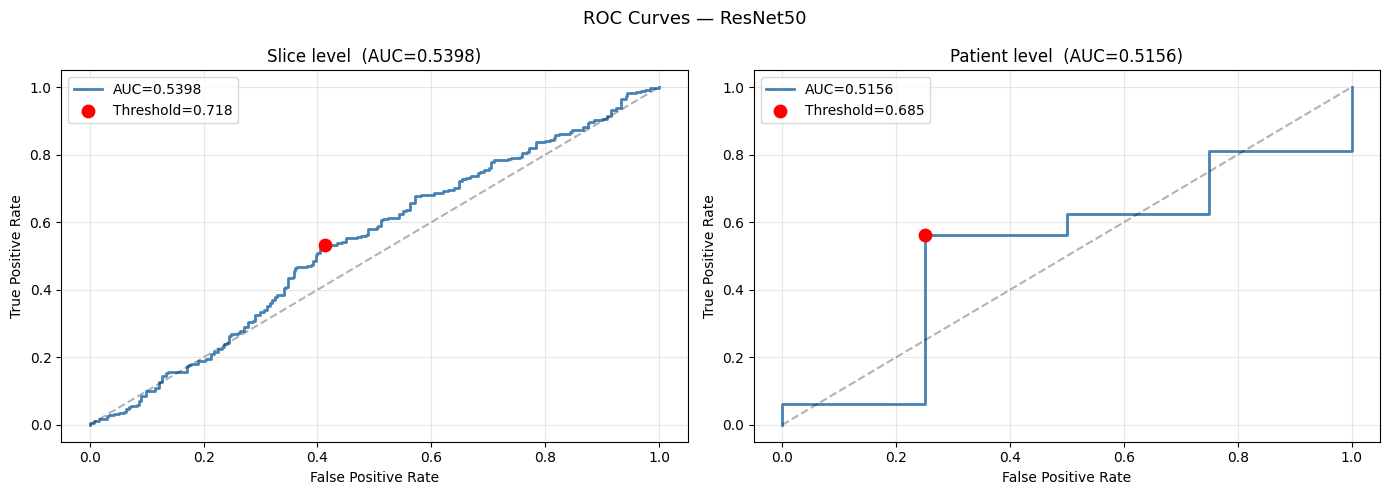

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (true, prob, title) in zip(axes, [
    (all_labels, all_probs, f'Slice level  (AUC={slice_auc:.4f})'),
    (pt_true,    pt_prob,   f'Patient level  (AUC={pt_auc:.4f})'),
]):
    fpr, tpr, thresholds = roc_curve(true, prob)
    opt_idx = np.argmax(tpr - fpr)
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={roc_auc_score(true,prob):.4f}')
    ax.scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=80, zorder=5,
               label=f'Threshold={thresholds[opt_idx]:.3f}')
    ax.plot([0,1],[0,1],'k--', alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — ResNet50', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curve.png'), dpi=120)
plt.show()

## ⚡ Inference speed (thesis requirement: < 1 sec)

In [25]:
base = model.module if isinstance(model, nn.DataParallel) else model
base = base.to('cpu').eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

with torch.no_grad():
    for _ in range(10): _ = base(dummy)

times = []
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        _  = base(dummy)
        times.append(time.perf_counter() - t0)

mean_ms = np.mean(times) * 1000
p95_ms  = np.percentile(times, 95) * 1000

print(f'CPU inference  mean : {mean_ms:.1f} ms')
print(f'CPU inference  p95  : {p95_ms:.1f} ms')
print(f'Thesis target (<1000ms): {"✅ PASS" if p95_ms < 1000 else "❌ FAIL"}')

model = model.to(device)

CPU inference  mean : 78.6 ms
CPU inference  p95  : 87.1 ms
Thesis target (<1000ms): ✅ PASS


## 💾 Save & download

In [26]:
from IPython.display import FileLink, display

print('Output files:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fp = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fp):
        print(f'  {f:<45} {os.path.getsize(fp)/1e6:.1f} MB')

print('\nClick to download best model:')
display(FileLink(CHECKPOINT_PATH))

Output files:
  confusion_matrix.png                          0.0 MB
  kfold_curves.png                              0.2 MB
  kfold_records.pkl                             0.0 MB
  roc_curve.png                                 0.1 MB
  test_results.json                             0.0 MB

Click to download best model:


/kaggle/working/resnet50_output/model/best_model.pth